# Smart Classroom Vision — Procedimiento de mejora de imagen
**Curso:** Percepción Computacional · **Equipo:** Imagen · **UPAO – 2026**

Este cuaderno muestra, paso a paso, las técnicas de **percepción de imagen** que el sistema *Smart Classroom Vision* aplica a las fotos del aula **antes** de detectar comportamientos con YOLO. Cada sección responde a un problema identificado en el informe y a un requisito funcional:

| Sección | Problema que resuelve | Requisito |
|---|---|---|
| 1. Reducción de ruido | P2 · Cámaras de aula generan ruido | RF01 · RNF08 |
| 2. Mejora de iluminación | P3 · Aulas oscuras o con contraluz | RF02 · RNF08 |
| 3. Control de calidad y nitidez | P2/P6 · Imágenes borrosas o no aptas (ISO/IEC 25012 y 5259) | RF03 · RNF08 · RNF09 |
| 4. Anonimización de rostros | P5 · Privacidad de los estudiantes (Ley 29733, ISO/IEC 42001) | RF07 · RNF02 · RNF10 |
| 5. Pipeline completo | P7 · Operar en tiempo real | RNF01 |

**Dataset de referencia para el modelo de comportamientos:** SCB-Dataset (Student Classroom Behavior) — https://github.com/Whiffe/SCB-dataset

**Imagen de prueba:** fotografía de un aula real del conjunto de datos público del repositorio *Student-behavior-detection-system* (CCNUZFW), enlazado en el repositorio del SCB-Dataset como dataset relacionado: https://github.com/CCNUZFW/Student-behavior-detection-system. Las imágenes del SCB-Dataset se distribuyen por Baidu Netdisk y Hugging Face; una vez descargadas, cualquiera de ellas puede usarse en este cuaderno.

**Cómo usarlo:** `Entorno de ejecución → Ejecutar todas`. Al ejecutar la celda de carga puedes subir una foto propia del aula (tomada con consentimiento) o una imagen del SCB-Dataset. Si no subes ninguna, se descarga automáticamente la imagen de aula de prueba.

In [1]:
import time, os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import data
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

os.makedirs("resultados", exist_ok=True)
plt.rcParams["figure.dpi"] = 110

def rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def mostrar(imagenes, titulos, archivo=None, cols=3):
    filas = int(np.ceil(len(imagenes) / cols))
    fig, ejes = plt.subplots(filas, cols, figsize=(4.2 * cols, 3.6 * filas))
    for eje in np.array(ejes).ravel():
        eje.axis("off")
    for eje, img, t in zip(np.array(ejes).ravel(), imagenes, titulos):
        eje.imshow(rgb(img) if img.ndim == 3 else img, cmap=None if img.ndim == 3 else "gray")
        eje.set_title(t, fontsize=10)
    plt.tight_layout()
    if archivo:
        plt.savefig(f"resultados/{archivo}", bbox_inches="tight")
    plt.show()

def comparar(referencia, img):
    return (round(psnr(referencia, img, data_range=255), 2),
            round(ssim(referencia, img, channel_axis=2, data_range=255), 3))

## Paso 0. Cargar la imagen del aula

Usando imagen de aula del dataset público: https://raw.githubusercontent.com/CCNUZFW/Student-behavior-detection-system/master/dataset/coco/train2017/0104.jpg
Tamaño de trabajo: (360, 640, 3)


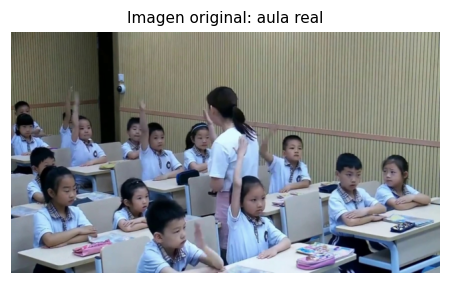

In [2]:
imagen = None
try:
    from google.colab import files          # solo existe en Google Colab
    print("Sube una foto del aula (o presiona Cancelar para usar la imagen de ejemplo)")
    subidos = files.upload()
    if subidos:
        nombre = list(subidos.keys())[0]
        imagen = cv2.imdecode(np.frombuffer(subidos[nombre], np.uint8), cv2.IMREAD_COLOR)
except Exception:
    pass

URL_AULA = ("https://raw.githubusercontent.com/CCNUZFW/Student-behavior-detection-system/"
            "master/dataset/coco/train2017/0104.jpg")          # aula real (dataset público)
if imagen is None:
    try:
        import urllib.request
        with urllib.request.urlopen(URL_AULA, timeout=60) as r:
            imagen = cv2.imdecode(np.frombuffer(r.read(), np.uint8), cv2.IMREAD_COLOR)
        print("Usando imagen de aula del dataset público:", URL_AULA)
    except Exception as e:
        imagen = cv2.cvtColor(data.astronaut(), cv2.COLOR_RGB2BGR)   # respaldo sin internet
        print("Sin conexión; usando imagen de respaldo de scikit-image:", e)

escala = 640 / imagen.shape[1]                 # resolución de trabajo: 640 px de ancho
original = cv2.resize(imagen, None, fx=escala, fy=escala, interpolation=cv2.INTER_AREA)
print("Tamaño de trabajo:", original.shape)
mostrar([original], ["Imagen original: aula real"], archivo="fig0_original.png", cols=1)

## 1. Reducción de ruido (RF01)
**Problema (P2):** las cámaras web de aula tienen sensores pequeños; con poca luz generan **ruido gaussiano** (granulado) y, por fallas de transmisión, **ruido impulsivo o sal y pimienta** (píxeles blancos y negros). El ruido confunde al detector y aumenta los falsos positivos.

**Técnicas comparadas:** filtro de media, gaussiano, mediana, bilateral y *Non-Local Means* (NLM).
**Métricas:** PSNR (dB, mayor es mejor) y SSIM (0 a 1, mayor es mejor) respecto de la imagen original.

             Ruido                   Filtro  PSNR (dB)   SSIM  Tiempo (ms)
0        Gaussiano     Sin filtro (ruidosa)      20.38  0.460          0.0
1        Gaussiano                Media 5x5      24.04  0.492          0.5
2        Gaussiano            Gaussiano 5x5      26.20  0.672          0.9
3        Gaussiano                Mediana 3      25.21  0.603          0.4
4        Gaussiano                Mediana 5      24.32  0.492          1.4
5        Gaussiano                Bilateral      27.22  0.723         20.6
6        Gaussiano                      NLM      26.09  0.706        532.3
7        Gaussiano  Mediana 3 + gaussiano 3      25.83  0.638          0.5
8   Sal y pimienta     Sin filtro (ruidosa)      18.28  0.457          0.0
9   Sal y pimienta                Media 5x5      23.71  0.476          0.4
10  Sal y pimienta            Gaussiano 5x5      25.29  0.634          0.9
11  Sal y pimienta                Mediana 3      28.96  0.827          0.4
12  Sal y pimienta       

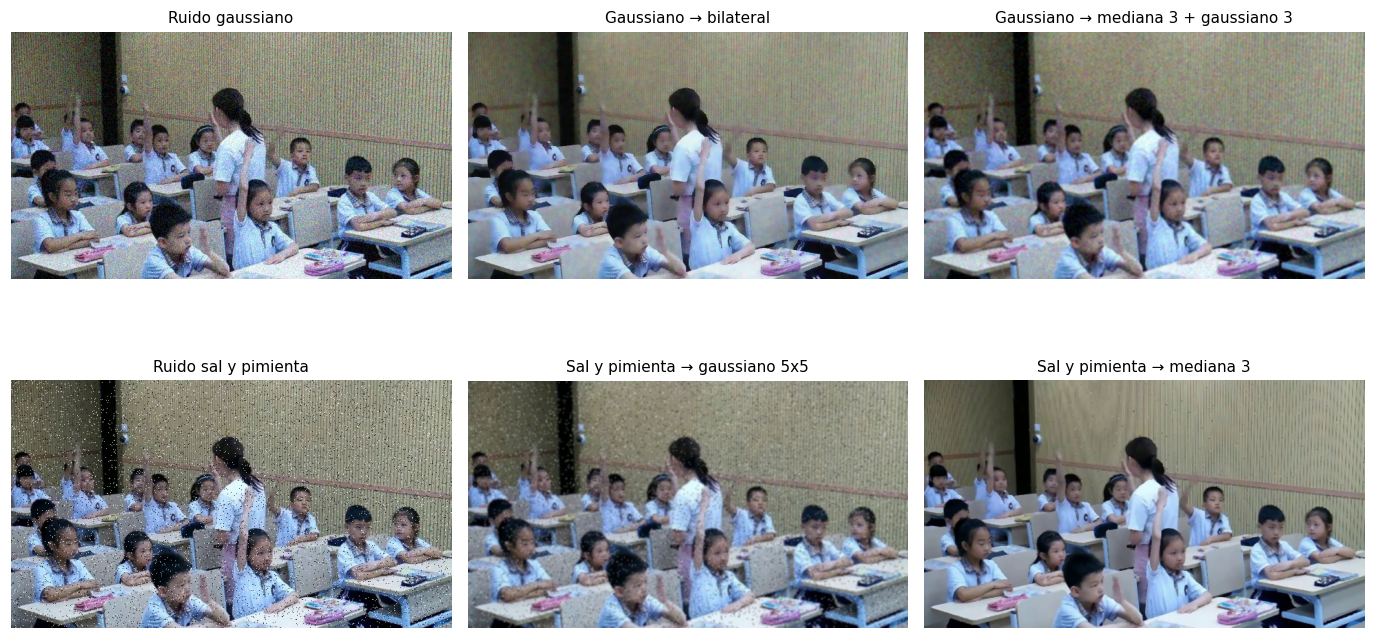

In [3]:
rng = np.random.default_rng(42)
# Ruido gaussiano (sigma = 25)
gauss = np.clip(original.astype(np.float32) + rng.normal(0, 25, original.shape), 0, 255).astype(np.uint8)
# Ruido sal y pimienta (5 % de los píxeles)
syp = original.copy()
mascara = rng.random(original.shape[:2])
syp[mascara < 0.025] = 0
syp[mascara > 0.975] = 255

filtros = {
    "Media 5x5":      lambda im: cv2.blur(im, (5, 5)),
    "Gaussiano 5x5":  lambda im: cv2.GaussianBlur(im, (5, 5), 0),
    "Mediana 3":      lambda im: cv2.medianBlur(im, 3),
    "Mediana 5":      lambda im: cv2.medianBlur(im, 5),
    "Bilateral":      lambda im: cv2.bilateralFilter(im, 9, 75, 75),
    "NLM":            lambda im: cv2.fastNlMeansDenoisingColored(im, None, 15, 15, 7, 21),
    "Mediana 3 + gaussiano 3": lambda im: cv2.GaussianBlur(cv2.medianBlur(im, 3), (3, 3), 0),
}

filas, resultados = [], {}
for tipo, ruidosa in [("Gaussiano", gauss), ("Sal y pimienta", syp)]:
    p0, s0 = comparar(original, ruidosa)
    filas.append([tipo, "Sin filtro (ruidosa)", p0, s0, 0.0])
    for nombre, f in filtros.items():
        t = time.perf_counter(); limpia = f(ruidosa); ms = (time.perf_counter() - t) * 1000
        p, s = comparar(original, limpia)
        filas.append([tipo, nombre, p, s, round(ms, 1)])
        resultados[(tipo, nombre)] = limpia

tabla_ruido = pd.DataFrame(filas, columns=["Ruido", "Filtro", "PSNR (dB)", "SSIM", "Tiempo (ms)"])
tabla_ruido.to_csv("resultados/tabla_ruido.csv", index=False)
display(tabla_ruido) if "display" in dir() else print(tabla_ruido)

mostrar([gauss, resultados[("Gaussiano", "Bilateral")], resultados[("Gaussiano", "Mediana 3 + gaussiano 3")],
         syp, resultados[("Sal y pimienta", "Gaussiano 5x5")], resultados[("Sal y pimienta", "Mediana 3")]],
        ["Ruido gaussiano", "Gaussiano → bilateral", "Gaussiano → mediana 3 + gaussiano 3",
         "Ruido sal y pimienta", "Sal y pimienta → gaussiano 5x5", "Sal y pimienta → mediana 3"],
        archivo="fig1_ruido.png")

**Interpretación (imagen del aula):** contra el ruido **sal y pimienta**, la **mediana 3** fue la mejor (mayor PSNR y SSIM), porque reemplaza los píxeles extremos por el valor central de su vecindad; la mediana 5 borra detalles finos, como los rostros de los estudiantes del fondo, y el bilateral y NLM casi no eliminan este ruido. Contra el ruido **gaussiano**, el **bilateral** obtuvo la mejor calidad, pero tarda unos 20 ms, mientras que el gaussiano 5x5 logra un resultado cercano en menos de 1 ms; NLM tarda cientos de milisegundos sin ventaja. La combinación **mediana 3 + gaussiano 3** es un buen compromiso cuando no se sabe qué tipo de ruido tiene la cámara. *Los valores cambian si subes otra imagen.*

## 2. Mejora de iluminación (RF02)
**Problema (P3):** en el aula la luz cambia según la hora, las ventanas generan contraluz y el proyector obliga a bajar las luces. En imágenes oscuras los estudiantes del fondo pierden detalle y el detector falla.

**Técnicas comparadas:** ecualización de histograma, **CLAHE** (ecualización adaptativa con límite de contraste) y corrección **gamma**.
**Métricas:** brillo medio (ideal entre 80 y 180), contraste (desviación estándar) y SSIM respecto de la original.

            Versión  Brillo medio  Contraste (desv. est.)   SSIM
0            Oscura          35.6                    25.5  0.406
1      Ecualización         120.8                    77.3  0.733
2             CLAHE          67.4                    47.6  0.689
3  Gamma automática         114.6                    43.2  0.941
4     Gamma + CLAHE         123.2                    56.1  0.886


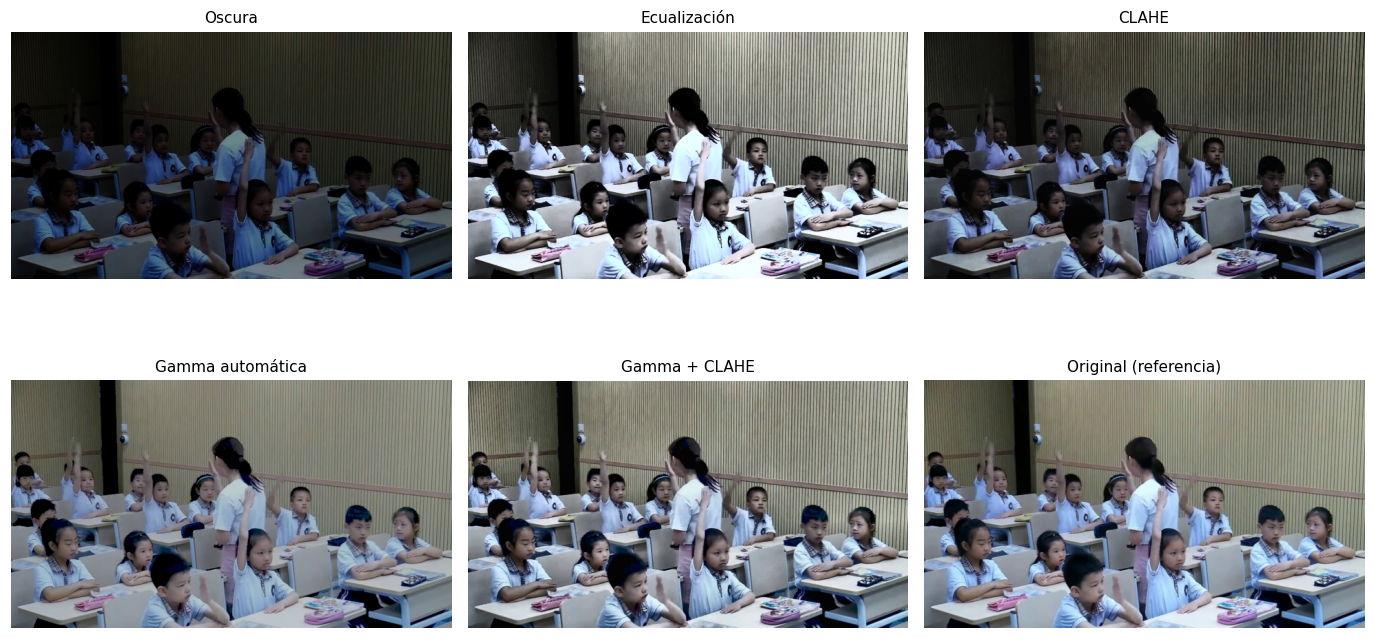

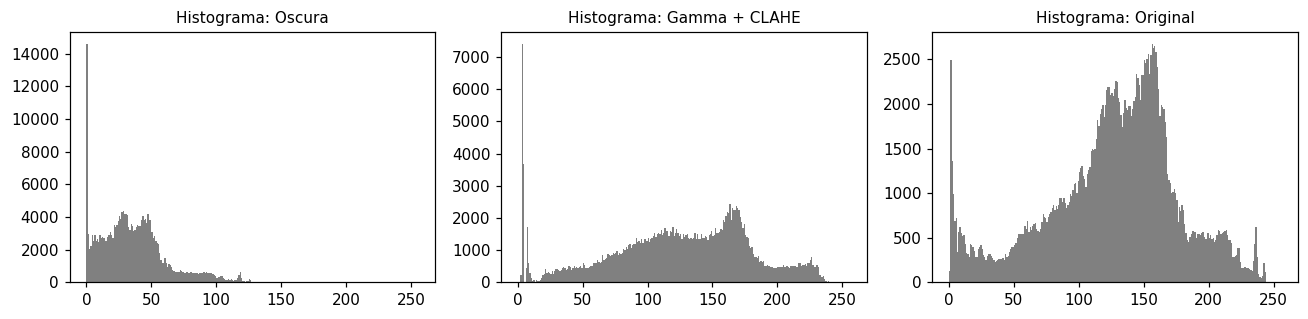

In [4]:
# Simulación de aula oscura: se reduce la exposición y se comprime el rango
oscura = np.clip(255 * (original / 255.0) ** 2.2 * 0.55, 0, 255).astype(np.uint8)

def ecualizar(im):
    ycc = cv2.cvtColor(im, cv2.COLOR_BGR2YCrCb)
    ycc[:, :, 0] = cv2.equalizeHist(ycc[:, :, 0])
    return cv2.cvtColor(ycc, cv2.COLOR_YCrCb2BGR)

def clahe(im, limite=2.0):
    lab = cv2.cvtColor(im, cv2.COLOR_BGR2LAB)
    lab[:, :, 0] = cv2.createCLAHE(clipLimit=limite, tileGridSize=(8, 8)).apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def gamma_auto(im):
    brillo = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY).mean() / 255
    g = np.log(0.5) / np.log(max(brillo, 1e-3))          # lleva el brillo medio a ~128
    tabla = np.array([((i / 255.0) ** g) * 255 for i in range(256)]).astype(np.uint8)
    return cv2.LUT(im, tabla)

variantes = {"Oscura": oscura, "Ecualización": ecualizar(oscura), "CLAHE": clahe(oscura),
             "Gamma automática": gamma_auto(oscura), "Gamma + CLAHE": clahe(gamma_auto(oscura))}
filas = []
for nombre, im in variantes.items():
    gris = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    filas.append([nombre, round(gris.mean(), 1), round(gris.std(), 1), comparar(original, im)[1]])
tabla_luz = pd.DataFrame(filas, columns=["Versión", "Brillo medio", "Contraste (desv. est.)", "SSIM"])
tabla_luz.to_csv("resultados/tabla_iluminacion.csv", index=False)
display(tabla_luz) if "display" in dir() else print(tabla_luz)

mostrar(list(variantes.values())[:3] + [variantes["Gamma automática"], variantes["Gamma + CLAHE"], original],
        list(variantes.keys())[:3] + ["Gamma automática", "Gamma + CLAHE", "Original (referencia)"],
        archivo="fig2_iluminacion.png")

fig, ejes = plt.subplots(1, 3, figsize=(12, 3))
for eje, (n, im) in zip(ejes, [("Oscura", oscura), ("Gamma + CLAHE", variantes["Gamma + CLAHE"]), ("Original", original)]):
    eje.hist(cv2.cvtColor(im, cv2.COLOR_BGR2GRAY).ravel(), bins=256, range=(0, 256), color="gray")
    eje.set_title(f"Histograma: {n}", fontsize=10)
plt.tight_layout(); plt.savefig("resultados/fig3_histogramas.png", bbox_inches="tight"); plt.show()

**Interpretación (imagen del aula):** la imagen oscura tiene un brillo medio cercano a 36, fuera del rango adecuado (60–200). La ecualización global recupera el brillo, pero exagera el contraste y se aleja de la original; CLAHE por sí solo se queda corto. La **gamma automática** logra la mayor similitud con la original (SSIM más alto) y, combinada con **CLAHE**, gana contraste local para distinguir a los estudiantes del fondo. El sistema usa **gamma automática + CLAHE**.

## 3. Control de calidad y nitidez (RF03 · ISO/IEC 25012 y 5259)
**Problema:** una imagen movida, oscura o muy ruidosa produce detecciones erróneas y, si entra al dataset, **degrada el entrenamiento** del modelo. La ISO/IEC 25012 y la ISO/IEC 5259-2 piden medir la calidad de los datos antes de usarlos.

**Técnica:** se calculan cuatro indicadores medibles y se decide si la imagen es **apta**:
- Brillo medio (exactitud de la exposición), contraste, nitidez (varianza del Laplaciano) y ruido estimado.
- Además, se prueba el **realce de nitidez** (*unsharp masking*) sobre una imagen desenfocada.

             Imagen  Brillo  Contraste  Nitidez (var. Laplaciano)  \
0          Original   125.4       51.2                     1017.6   
1   Ruido gaussiano   125.2       52.6                     6357.8   
2            Oscura    35.6       25.5                      306.2   
3            Movida   125.4       46.1                       74.3   
4   Movida + realce   125.5       49.3                      232.4   
5  Oscura corregida   123.2       56.1                     2476.2   

   Ruido estimado (sigma) Resultado  
0                    1.35      Apta  
1                   16.49   No apta  
2                    0.80   No apta  
3                    0.33   No apta  
4                    0.55      Apta  
5                    2.20      Apta  


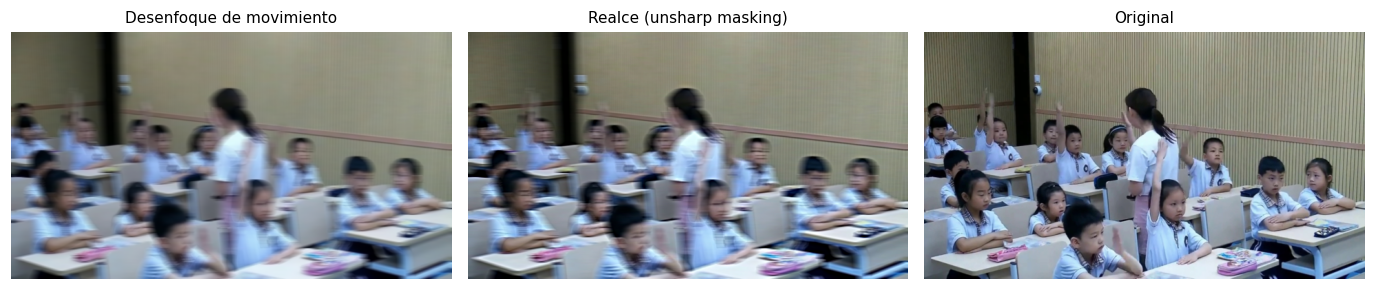

In [5]:
UMBRALES = {"brillo_min": 60, "brillo_max": 200, "contraste_min": 30, "nitidez_min": 100, "ruido_max": 10}

def estimar_ruido(gris):
    # Estimación rápida de la desviación del ruido (método de Immerkær, 1996)
    M = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], dtype=np.float64)
    h, w = gris.shape
    conv = cv2.filter2D(gris.astype(np.float64), -1, M)[1:-1, 1:-1]
    return np.sqrt(np.pi / 2) * np.abs(conv).sum() / (6 * (w - 2) * (h - 2))

def evaluar_calidad(im):
    gris = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)
    m = {"Brillo": round(float(gris.mean()), 1),
         "Contraste": round(float(gris.std()), 1),
         "Nitidez (var. Laplaciano)": round(float(cv2.Laplacian(gris, cv2.CV_64F).var()), 1),
         "Ruido estimado (sigma)": round(float(estimar_ruido(gris)), 2)}
    apta = (UMBRALES["brillo_min"] <= m["Brillo"] <= UMBRALES["brillo_max"]
            and m["Contraste"] >= UMBRALES["contraste_min"]
            and m["Nitidez (var. Laplaciano)"] >= UMBRALES["nitidez_min"]
            and m["Ruido estimado (sigma)"] <= UMBRALES["ruido_max"])
    m["Resultado"] = "Apta" if apta else "No apta"
    return m

# Desenfoque de movimiento simulado (estudiante o cámara en movimiento)
k = np.zeros((15, 15)); k[7, :] = 1 / 15
movida = cv2.filter2D(original, -1, k)
enfocada = cv2.addWeighted(movida, 1.8, cv2.GaussianBlur(movida, (0, 0), 3), -0.8, 0)   # unsharp masking

casos = {"Original": original, "Ruido gaussiano": gauss, "Oscura": oscura,
         "Movida": movida, "Movida + realce": enfocada, "Oscura corregida": variantes["Gamma + CLAHE"]}
tabla_calidad = pd.DataFrame([{"Imagen": n, **evaluar_calidad(im)} for n, im in casos.items()])
tabla_calidad.to_csv("resultados/tabla_calidad.csv", index=False)
display(tabla_calidad) if "display" in dir() else print(tabla_calidad)
mostrar([movida, enfocada, original], ["Desenfoque de movimiento", "Realce (unsharp masking)", "Original"],
        archivo="fig4_nitidez.png")

**Interpretación:** la imagen con ruido, la oscura y la movida se clasifican como *no aptas*, mientras que la oscura corregida vuelve a ser *apta*. En esta imagen, el realce por *unsharp masking* elevó la nitidez de la imagen movida por encima del umbral, por lo que un desenfoque moderado sí puede recuperarse; un desenfoque fuerte, en cambio, debe descartarse. La función `evaluar_calidad` convierte criterios de la ISO/IEC 25012 (exactitud y precisión del dato) en **umbrales verificables**. En el sistema, las imágenes *no aptas* generan una alerta y no se usan para calcular indicadores; en la preparación del dataset (ISO/IEC 5259), se descartan o se corrigen antes del entrenamiento.

## 4. Anonimización de rostros (RF07 · Ley 29733 · ISO/IEC 42001)
**Problema (P5):** el sistema capta la imagen de estudiantes, que es un dato personal. Para cumplir la Ley N.° 29733 y los controles de riesgo de la ISO/IEC 42001, los rostros se ocultan **antes** de mostrar cualquier imagen y no se guarda video.

**Técnicas comparadas:** dos detectores de rostros (Haar clásico y una red neuronal SSD de OpenCV) y dos formas de ocultarlos (difuminado gaussiano y pixelado).

           Detector  Rostros detectados  Tiempo (ms)
0    Haar (clásico)                   3        164.2
1  Red neuronal SSD                  11        152.6


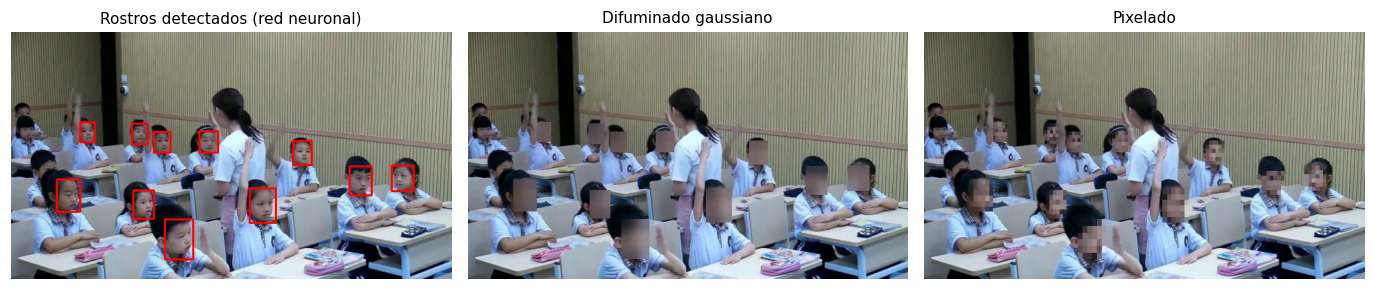

In [6]:
import urllib.request
# Detector de rostros basado en red neuronal (SSD ResNet-10, OpenCV) y detector clásico Haar
PROTO = "deploy.prototxt"
MODELO = "res10_300x300_ssd_iter_140000.caffemodel"
if not os.path.exists(MODELO):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt", PROTO)
    urllib.request.urlretrieve("https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/"
                               "res10_300x300_ssd_iter_140000.caffemodel", MODELO)
red_rostros = cv2.dnn.readNetFromCaffe(PROTO, MODELO)
haar = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def rostros_dnn(im, umbral=0.5):
    h, w = im.shape[:2]
    red_rostros.setInput(cv2.dnn.blobFromImage(im, 1.0, (w, h), (104, 177, 123)))
    det = red_rostros.forward()[0, 0]
    cajas = []
    for d in det[det[:, 2] > umbral]:
        x1, y1, x2, y2 = (d[3:7] * [w, h, w, h]).astype(int)
        x1, y1 = max(x1, 0), max(y1, 0)
        cajas.append((x1, y1, max(x2 - x1, 1), max(y2 - y1, 1)))
    return cajas

def rostros_haar(im):
    gris = cv2.equalizeHist(cv2.cvtColor(im, cv2.COLOR_BGR2GRAY))
    return list(haar.detectMultiScale(gris, scaleFactor=1.1, minNeighbors=5, minSize=(12, 12)))

def anonimizar(im, modo="difuminado", cajas=None):
    salida = im.copy()
    for (x, y, w, h) in (rostros_dnn(im) if cajas is None else cajas):
        roi = salida[y:y + h, x:x + w]
        if roi.size == 0:
            continue
        if modo == "difuminado":
            salida[y:y + h, x:x + w] = cv2.GaussianBlur(roi, (31, 31), 20)
        else:
            chico = cv2.resize(roi, (6, 6), interpolation=cv2.INTER_LINEAR)
            salida[y:y + h, x:x + w] = cv2.resize(chico, (w, h), interpolation=cv2.INTER_NEAREST)
    return salida

filas = []
for nombre, f in [("Haar (clásico)", rostros_haar), ("Red neuronal SSD", rostros_dnn)]:
    t = time.perf_counter(); cajas = f(original); ms = (time.perf_counter() - t) * 1000
    filas.append([nombre, len(cajas), round(ms, 1)])
tabla_rostros = pd.DataFrame(filas, columns=["Detector", "Rostros detectados", "Tiempo (ms)"])
tabla_rostros.to_csv("resultados/tabla_rostros.csv", index=False)
display(tabla_rostros) if "display" in dir() else print(tabla_rostros)

cajas = rostros_dnn(original)
marcada = original.copy()
for (x, y, w, h) in cajas:
    cv2.rectangle(marcada, (x, y), (x + w, y + h), (0, 0, 255), 2)
mostrar([marcada, anonimizar(original, cajas=cajas), anonimizar(original, "pixelado", cajas=cajas)],
        ["Rostros detectados (red neuronal)", "Difuminado gaussiano", "Pixelado"], archivo="fig5_anonimizacion.png")

**Interpretación:** en el aula, el detector clásico **Haar** encontró muy pocos rostros, porque los estudiantes están lejos, girados o con la mano delante de la cara; la **red neuronal SSD** detectó muchos más en un tiempo similar, por lo que es el detector elegido. Tanto el difuminado como el pixelado impiden reconocer a la persona sin ocultar la postura del cuerpo (por ejemplo, la mano levantada), que es lo que necesita el modelo de comportamientos. El sistema usa el **difuminado** por ser menos intrusivo visualmente. Algunos rostros de perfil o muy pequeños aún pueden escaparse, por lo que en el sistema nunca se guardan imágenes, ni siquiera anonimizadas.

## 5. Pipeline completo y tiempo de procesamiento (RNF01)
Se encadenan las etapas del prototipo: **control de calidad → reducción de ruido → corrección de iluminación → anonimización**. Como aclarar una imagen oscura también amplifica su ruido, primero se comparan dos órdenes posibles (A y B) sobre un aula oscura con ruido y se elige el que conserva mejor la imagen. Luego se mide el tiempo por cuadro para verificar el requisito de tiempo real. Se mide el tiempo por cuadro para verificar que el preprocesamiento no impida trabajar en tiempo real.

                            Orden de etapas   SSIM  Ruido estimado (sigma)  \
0  A: iluminación → mediana 3 + gaussiano 3  0.626                    0.68   
1                B: bilateral → iluminación  0.744                    6.88   

   Tiempo (ms)  
0          4.9  
1         24.2  


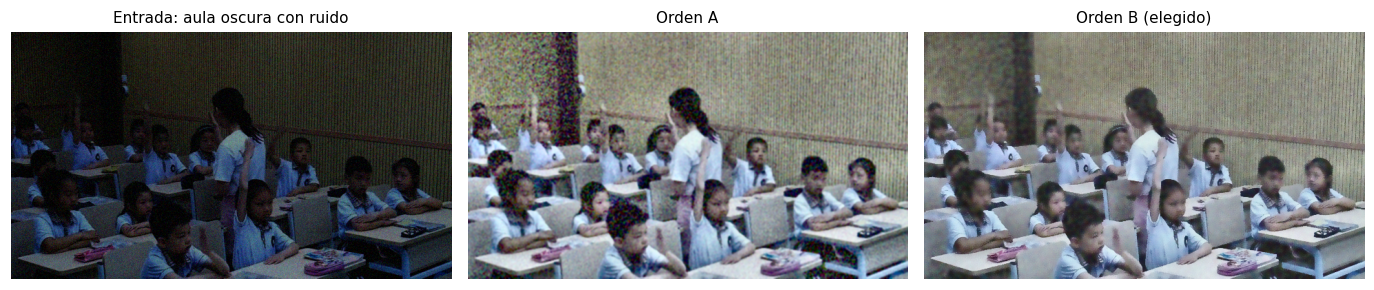

                                          Etapas  Tiempo medio (ms/cuadro)  \
0                  Calidad + ruido + iluminación                      27.2   
1  Calidad + ruido + iluminación + anonimización                     133.1   

   Cuadros por segundo  
0                 36.8  
1                  7.5  
Calidad de la entrada: {'Brillo': 35.8, 'Contraste': 25.7, 'Nitidez (var. Laplaciano)': 1423.0, 'Ruido estimado (sigma)': 7.53, 'Resultado': 'No apta'}
Calidad de la salida:  {'Brillo': 126.7, 'Contraste': 44.6, 'Nitidez (var. Laplaciano)': 1686.4, 'Ruido estimado (sigma)': 6.64, 'Resultado': 'Apta'}


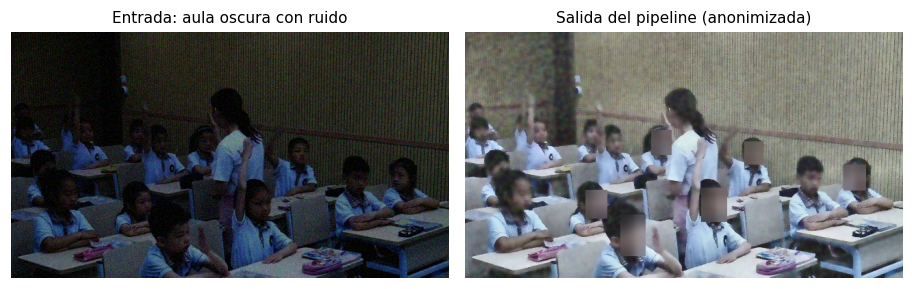

In [7]:
def orden_a(im):   # iluminación primero y luego mediana 3 + gaussiano 3
    return cv2.GaussianBlur(cv2.medianBlur(clahe(gamma_auto(im)), 3), (3, 3), 0)

def orden_b(im):   # filtro bilateral primero (conserva bordes) y luego iluminación
    return clahe(gamma_auto(cv2.bilateralFilter(im, 9, 40, 40)), 1.5)

entrada = np.clip(oscura.astype(np.float32) + rng.normal(0, 12, oscura.shape), 0, 255).astype(np.uint8)
filas = []
for nombre, f in [("A: iluminación → mediana 3 + gaussiano 3", orden_a), ("B: bilateral → iluminación", orden_b)]:
    f(entrada); t = time.perf_counter(); r = f(entrada); ms = (time.perf_counter() - t) * 1000
    gris = cv2.cvtColor(r, cv2.COLOR_BGR2GRAY)
    filas.append([nombre, comparar(original, r)[1], round(float(estimar_ruido(gris)), 2), round(ms, 1)])
tabla_orden = pd.DataFrame(filas, columns=["Orden de etapas", "SSIM", "Ruido estimado (sigma)", "Tiempo (ms)"])
tabla_orden.to_csv("resultados/tabla_orden.csv", index=False)
display(tabla_orden) if "display" in dir() else print(tabla_orden)
mostrar([entrada, orden_a(entrada), orden_b(entrada)],
        ["Entrada: aula oscura con ruido", "Orden A", "Orden B (elegido)"], archivo="fig6_orden.png")

def preprocesar(im, con_anonimizacion=True):
    calidad = evaluar_calidad(im)
    limpia = orden_b(im)                            # ruido + iluminación (orden elegido)
    return (anonimizar(limpia) if con_anonimizacion else limpia), calidad

def medir(anon, n=20):
    tiempos = []
    for _ in range(n):
        t = time.perf_counter(); preprocesar(entrada, anon); tiempos.append((time.perf_counter() - t) * 1000)
    return np.mean(tiempos)

t_sin, t_con = medir(False), medir(True)
tabla_tiempos = pd.DataFrame([["Calidad + ruido + iluminación", round(t_sin, 1), round(1000 / t_sin, 1)],
                              ["Calidad + ruido + iluminación + anonimización", round(t_con, 1), round(1000 / t_con, 1)]],
                             columns=["Etapas", "Tiempo medio (ms/cuadro)", "Cuadros por segundo"])
tabla_tiempos.to_csv("resultados/tabla_tiempos.csv", index=False)
display(tabla_tiempos) if "display" in dir() else print(tabla_tiempos)
salida, calidad = preprocesar(entrada)
print("Calidad de la entrada:", calidad)
print("Calidad de la salida: ", evaluar_calidad(salida))
mostrar([entrada, salida], ["Entrada: aula oscura con ruido", "Salida del pipeline (anonimizada)"],
        archivo="fig7_pipeline.png", cols=2)

**Interpretación:** el **orden B** (bilateral antes de aclarar) conserva mejor la imagen (SSIM más alto). El orden A deja manchas de ruido de color, porque al aclarar primero se amplifica el ruido y luego el filtro pequeño ya no lo elimina; su «ruido estimado» es menor solo porque ese indicador mide variaciones finas y no las manchas. Con el orden B, el preprocesamiento sin anonimización se mantiene dentro de los 30 ms por cuadro que exige el RNF01, y la imagen oscura pasa de *no apta* a *apta*. La anonimización es la etapa más costosa, por lo que en el prototipo se aplica solo a la imagen que se muestra en pantalla.

## 6. (Opcional) Entrenamiento del modelo de comportamientos con SCB-Dataset
Las celdas siguientes están comentadas para no consumir tiempo. Para entrenar:
1. Descargar el dataset desde **https://github.com/Whiffe/SCB-dataset** (seguir los enlaces de descarga del repositorio).
2. Aplicar `evaluar_calidad` a cada imagen y descartar las no aptas (ISO/IEC 5259).
3. Agregar imágenes propias del aula, etiquetadas y con consentimiento.
4. Activar GPU: `Entorno de ejecución → Cambiar tipo de entorno → GPU`.

In [8]:
# !pip install -q ultralytics
# from ultralytics import YOLO
# modelo = YOLO("yolo11n.pt")
# modelo.train(data="scb_aula.yaml", epochs=100, imgsz=640)
# metricas = modelo.val()
# print("mAP@0.5:", metricas.box.map50)      # meta del RNF06: >= 0.70

## Conclusiones
1. El ruido impulsivo se elimina mejor con la **mediana 3** y el ruido gaussiano con el **bilateral**; NLM es demasiado lento para tiempo real.
2. La combinación **gamma automática + CLAHE** corrige aulas oscuras y deja el brillo en el rango adecuado para el detector.
3. La función de **control de calidad** traduce la ISO/IEC 25012 y la ISO/IEC 5259 en umbrales medibles para aceptar o rechazar imágenes.
4. La **anonimización** protege la identidad de los estudiantes sin afectar la información de postura que necesita el modelo.
5. En un aula oscura conviene filtrar el ruido **antes** de aclarar (bilateral → gamma → CLAHE). El preprocesamiento cumple el tiempo del RNF01; la detección de rostros con red neuronal es más precisa que Haar, pero es la etapa más costosa.